In [4]:
import pandas as pd

matches = pd.read_csv(r'C:/Users/hp/OneDrive/Documents/IPL_Data_Analysis_Folder/Data/matches.csv')
deliveries = pd.read_csv(r'C:/Users/hp/OneDrive/Documents/IPL_Data_Analysis_Folder/Data/deliveries.csv')

matches.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_28940\1690964641.py:4: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  deliveries = pd.read_csv(r'C:/Users/hp/OneDrive/Documents/IPL_Data_Analysis_Folder/Data/deliveries.csv')


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,18-04-2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,19-04-2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,19-04-2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,20-04-2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,20-04-2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
print(matches.shape)
print(deliveries.shape)

(1095, 20)
(260920, 21)


In [6]:
ml_df = matches[['season','team1','team2','toss_winner','toss_decision','venue','winner']]

ml_df.head()

,season,team1,team2,toss_winner,toss_decision,venue,winner
0,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Kolkata Knight Riders
1,2007/08,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings
2,2007/08,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi Daredevils
3,2007/08,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Royal Challengers Bangalore
4,2007/08,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Eden Gardens,Kolkata Knight Riders


In [7]:
ml_df = ml_df.dropna()

ml_df.shape

(1095, 7)

In [8]:
ml_df['winner'].value_counts()


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
No Result                        5
Rising Pune Supergiants          5
Name: count, dtype: int64

In [9]:
ml_df = ml_df[ml_df['winner'] != 'No Result']

ml_df['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [10]:
ml_df.replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Royal Challengers Bengaluru':'Royal Challengers Bangalore',
    'Rising Pune Supergiants':'Rising Pune Supergiant'
}, inplace=True)

In [11]:
ml_df['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    123
Delhi Capitals                 115
Punjab Kings                   112
Rajasthan Royals               112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [12]:
X = ml_df[['season','team1','team2','toss_winner','toss_decision','venue']]
y = ml_df['winner']

In [13]:
X = pd.get_dummies(X)

In [14]:
X.shape

(1090, 122)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(872, 122)
(218, 122)


In [16]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(872, 122)
(218, 122)


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5321100917431193


In [21]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[24,  0,  0,  0,  0,  0,  0,  1,  1,  0,  2,  2,  0,  1,  2],
       [ 0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  6,  1,  1,  0,  1,  0,  2,  1,  3,  2,  0,  0,  2],
       [ 0,  0,  0,  2,  0,  0,  0,  0,  2,  0,  0,  0,  0,  1,  0],
       [ 1,  0,  1,  0,  5,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0, 15,  0,  3,  0,  0,  0,  0,  1,  2],
       [ 0,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  0,  1,  0,  0,  0,  1,  0, 19,  0,  1,  2,  0,  0,  1],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 1,  0,  2,  0,  0,  0,  2,  1,  1,  0,  9,  1,  0,  2,  1],
       [ 4,  0,  1,  0,  0,  0,  2,  0,  2,  1,  4, 10,  0,  1,  0],
       [ 0,  0,  0,  1,  0,  0,  1,  0,  0,  0,  0,  0,  1,  0,  1],
       [ 3,  0,  2,  0,  0,  0,  2,  0,  5,  0,  2,  0,  0, 14,  1],
       [ 1,  0,  0,  0,  0,  0,  0

In [22]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

team1_Chennai Super Kings            0.029196
team2_Mumbai Indians                 0.027428
team1_Mumbai Indians                 0.025667
team2_Punjab Kings                   0.023386
team1_Sunrisers Hyderabad            0.022659
team2_Kolkata Knight Riders          0.022451
team2_Chennai Super Kings            0.021805
team1_Kolkata Knight Riders          0.021343
team1_Royal Challengers Bangalore    0.020491
toss_winner_Delhi Capitals           0.019245
dtype: float64

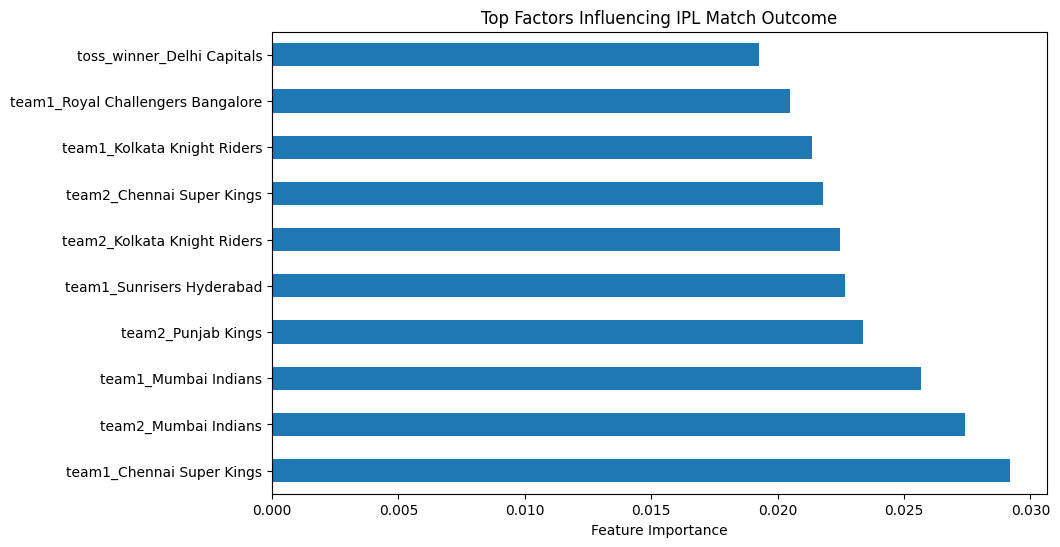

In [23]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

top_features.plot(kind='barh')

plt.title("Top Factors Influencing IPL Match Outcome")

plt.xlabel("Feature Importance")

plt.show()

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [25]:
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))

Logistic Regression: 0.5275229357798165
Decision Tree: 0.4541284403669725
Random Forest: 0.536697247706422


In [26]:
def predict_winner(season, team1, team2, toss_winner, toss_decision, venue):

    input_df = pd.DataFrame({
        'season':[season],
        'team1':[team1],
        'team2':[team2],
        'toss_winner':[toss_winner],
        'toss_decision':[toss_decision],
        'venue':[venue]
    })

    input_encoded = pd.get_dummies(input_df)

    input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)

    prediction = model.predict(input_encoded)

    return prediction[0]

In [32]:
predict_winner(
    season=2024,
    team1="Mumbai Indians",
    team2="Rajasthan Royals",
    toss_winner="Mumbai Indians",
    toss_decision="bat",
    venue="Wankhede Stadium"
)

'Rajasthan Royals'

In [33]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

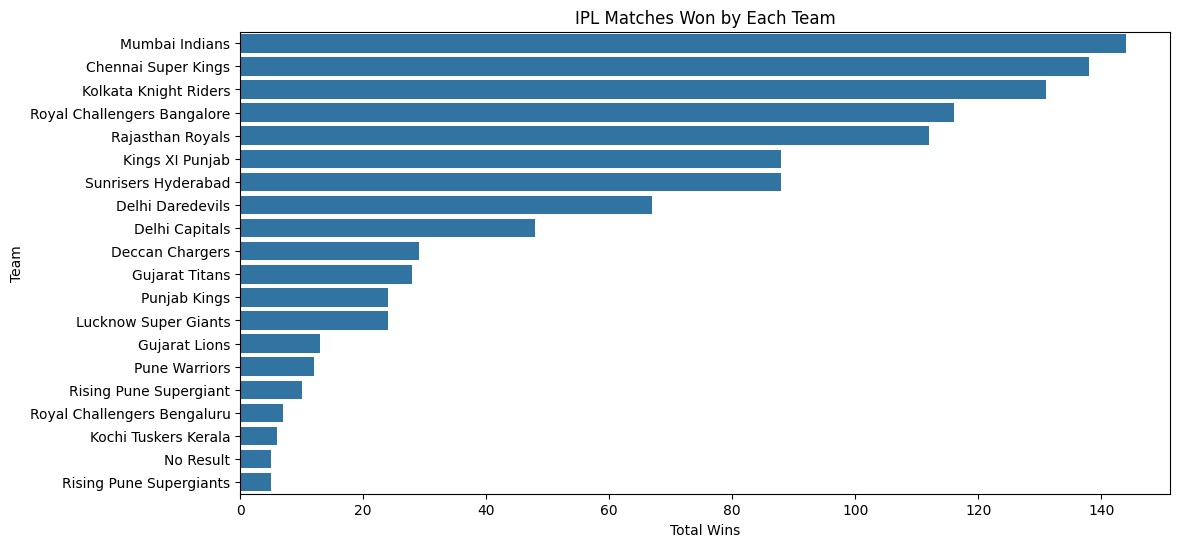

In [37]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='winner',
    data=matches,
    order=matches['winner'].value_counts().index
)

plt.title("IPL Matches Won by Each Team")
plt.xlabel("Total Wins")
plt.ylabel("Team")

plt.show()

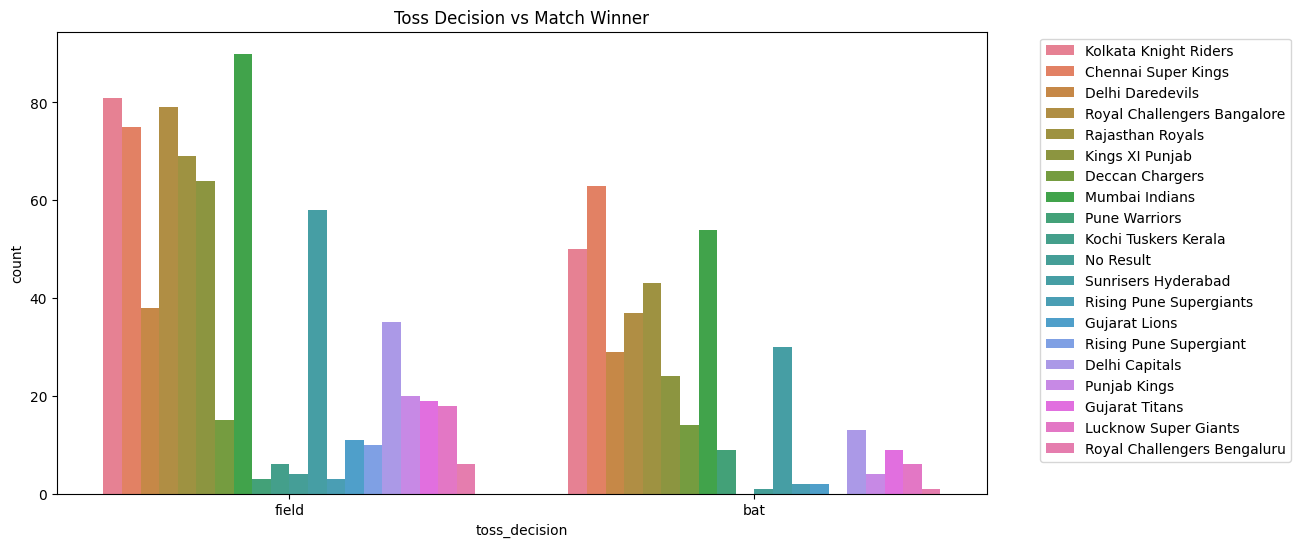

In [41]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    x='toss_decision',
    data=matches,
    hue='winner'
)

plt.title("Toss Decision vs Match Winner")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()